# **Car Price Prediction and Classification using Machine Learning**

## **Problem Statement:**


The goal of this project is to build machine learning models that can predict car prices and classify cars based on their key features.
We aim to apply regression algorithms for price prediction and classification algorithms for brand/fuel type prediction, using a real-world Indian car dataset.
Additionally, we will perform dimensionality reduction and clustering to gain deeper insights.

## **Import Libraries**


We import all necessary Python libraries like pandas, numpy, matplotlib, seaborn, and machine learning modules from sklearn to support data handling, visualization, model building, and evaluation.

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## **Load Dataset**


The car dataset containing brand, model, year, fuel type, transmission, price, mileage, engine size, seating capacity, and service cost is loaded for further analysis.

In [2]:
# Load the dataset
df = pd.read_csv('car_dataset_india.csv')

## **Data Preprocessing and Exploratory Data Analysis (EDA)**


* We clean the dataset by handling missing values, encoding categorical variables, converting data types, and preparing it for model training.


* We explore the dataset through descriptive statistics and visualizations to understand patterns, distributions, outliers, and relationships between variables.

In [3]:
print(df.head())

   Car_ID          Brand   Model  Year Fuel_Type Transmission      Price  \
0       1         Toyota  Innova  2024       CNG       Manual  2020000.0   
1       2            Kia     EV6  2023    Diesel       Manual  1770000.0   
2       3  Maruti Suzuki   Dzire  2016    Petrol       Manual  3430000.0   
3       4          Honda   Amaze  2019    Petrol       Manual  1610000.0   
4       5          Honda    City  2015  Electric       Manual  1840000.0   

   Mileage  Engine_CC  Seating_Capacity  Service_Cost  
0     27.3        800                 4       24100.0  
1     16.4       2500                 7       18800.0  
2     17.6       2000                 6       24700.0  
3     19.2       2500                 6       23300.0  
4     15.8       1000                 5        5800.0  


In [4]:
print(df.tail())

      Car_ID        Brand          Model  Year Fuel_Type Transmission  \
9995    9996  Tata Motors         Altroz  2021       CNG    Automatic   
9996    9997        Honda           WR-V  2024    Diesel    Automatic   
9997    9998     Mahindra         XUV300  2020  Electric       Manual   
9998    9999      Renault         Duster  2020    Diesel       Manual   
9999   10000       Toyota  Urban Cruiser  2018       CNG    Automatic   

          Price  Mileage  Engine_CC  Seating_Capacity  Service_Cost  
9995  1900000.0     24.9       2500                 7        7100.0  
9996  1270000.0     21.4       1000                 6       18300.0  
9997  3050000.0     27.0       1200                 4        7700.0  
9998  2390000.0     24.3       1800                 7       15700.0  
9999  1500000.0     21.5       1200                 6       18600.0  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car_ID            10000 non-null  int64  
 1   Brand             10000 non-null  object 
 2   Model             10000 non-null  object 
 3   Year              10000 non-null  int64  
 4   Fuel_Type         10000 non-null  object 
 5   Transmission      10000 non-null  object 
 6   Price             10000 non-null  float64
 7   Mileage           10000 non-null  float64
 8   Engine_CC         10000 non-null  int64  
 9   Seating_Capacity  10000 non-null  int64  
 10  Service_Cost      10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB
None


In [6]:
print(df.describe())

            Car_ID          Year         Price       Mileage     Engine_CC  \
count  10000.00000  10000.000000  1.000000e+04  10000.000000  10000.000000   
mean    5000.50000   2019.543800  1.946064e+06     19.967300   1542.070000   
std     2886.89568      2.877553  8.837945e+05      5.778583    557.487394   
min        1.00000   2015.000000  4.000000e+05     10.000000    800.000000   
25%     2500.75000   2017.000000  1.180000e+06     14.900000   1000.000000   
50%     5000.50000   2020.000000  1.950000e+06     20.000000   1500.000000   
75%     7500.25000   2022.000000  2.700000e+06     25.000000   2000.000000   
max    10000.00000   2024.000000  3.500000e+06     30.000000   2500.000000   

       Seating_Capacity  Service_Cost  
count      10000.000000  10000.000000  
mean           5.515400  14969.130000  
std            1.121556   5777.753741  
min            4.000000   5000.000000  
25%            5.000000   9900.000000  
50%            6.000000  15000.000000  
75%            7.

In [7]:
# Statistical summaries
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n", df.median(numeric_only=True))
print("Standard Deviation:\n", df.std(numeric_only=True))
print("Min:\n", df.min(numeric_only=True))
print("Max:\n", df.max(numeric_only=True))
print("Count:\n", df.count(numeric_only=True))

Mean:
 Car_ID              5.000500e+03
Year                2.019544e+03
Price               1.946064e+06
Mileage             1.996730e+01
Engine_CC           1.542070e+03
Seating_Capacity    5.515400e+00
Service_Cost        1.496913e+04
dtype: float64
Median:
 Car_ID                 5000.5
Year                   2020.0
Price               1950000.0
Mileage                  20.0
Engine_CC              1500.0
Seating_Capacity          6.0
Service_Cost          15000.0
dtype: float64
Standard Deviation:
 Car_ID                2886.895680
Year                     2.877553
Price               883794.510719
Mileage                  5.778583
Engine_CC              557.487394
Seating_Capacity         1.121556
Service_Cost          5777.753741
dtype: float64
Min:
 Car_ID                   1.0
Year                  2015.0
Price               400000.0
Mileage                 10.0
Engine_CC              800.0
Seating_Capacity         4.0
Service_Cost          5000.0
dtype: float64
Max:
 Car_ID   

In [8]:
# Check for missing values
print(df.isnull().sum())

# Encode categorical variables
label_encoders = {}
for column in ['Brand', 'Model', 'Fuel_Type', 'Transmission']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Feature Scaling
scaler = StandardScaler()
df[['Price', 'Mileage', 'Engine_CC', 'Service_Cost']] = scaler.fit_transform(df[['Price', 'Mileage', 'Engine_CC', 'Service_Cost']])

Car_ID              0
Brand               0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Price               0
Mileage             0
Engine_CC           0
Seating_Capacity    0
Service_Cost        0
dtype: int64


## **Correlation Matrix**


A correlation heatmap is generated to observe the strength of relationships between numeric variables.
This helps in identifying multicollinearity and selecting important features for modeling.

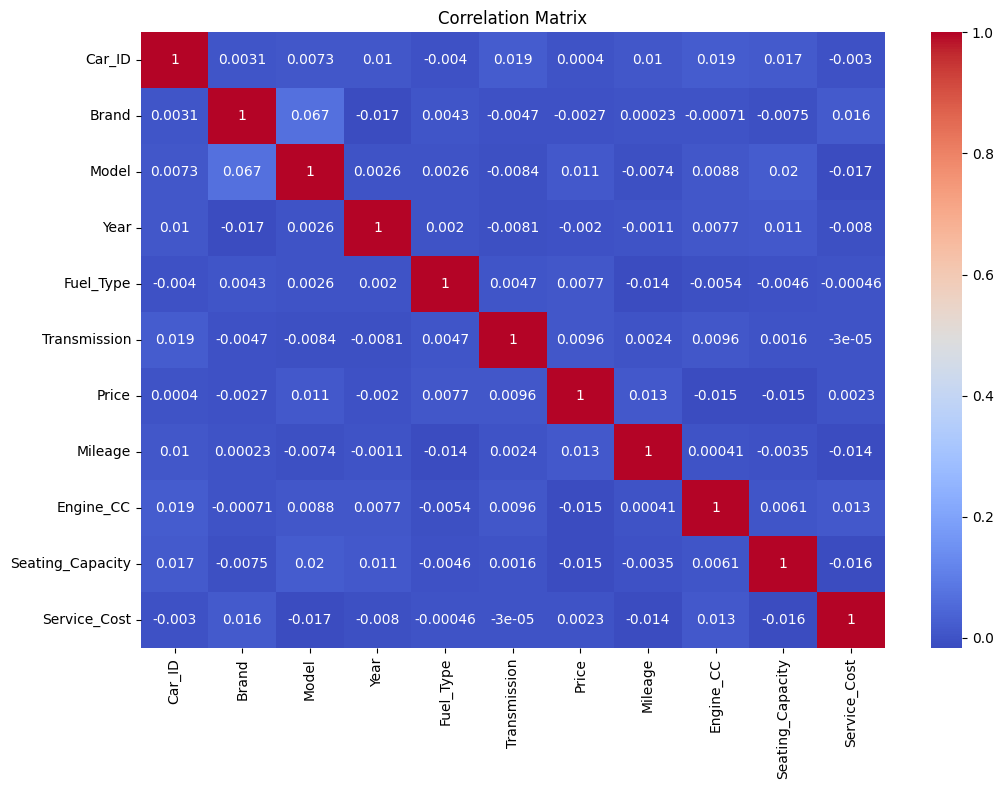

In [9]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## **Price Distribution**


This histogram provides an overview of how car prices are distributed across the dataset.


Helps identify the spread, skewness, and peak of the price distribution.


The kde=True adds a density curve to better visualize the underlying distribution shape.

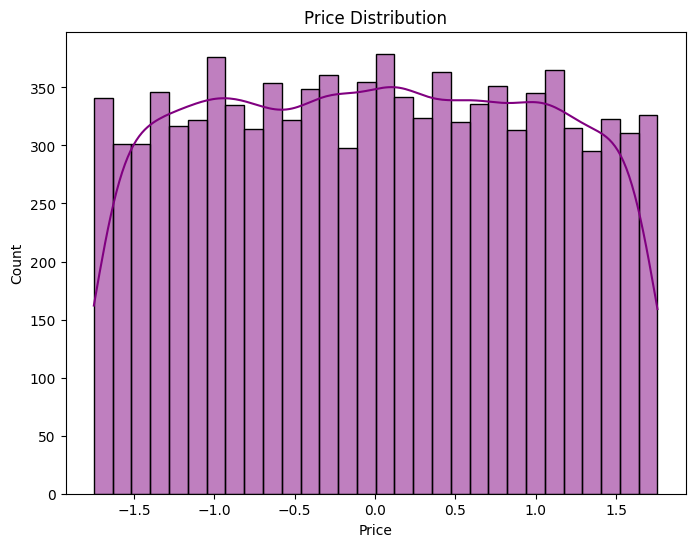

In [10]:
# Price Distribution
plt.figure(figsize=(8,6))
sns.histplot(df['Price'], bins=30, kde=True, color='purple')
plt.title('Price Distribution')
plt.show()

## **Fuel Type vs Price**


This boxplot compares the car prices based on different fuel types (e.g., Petrol, Diesel, Electric).


Purpose: Highlights how car prices vary with the fuel type.


Observation: Useful to detect outliers and median price differences among categories.

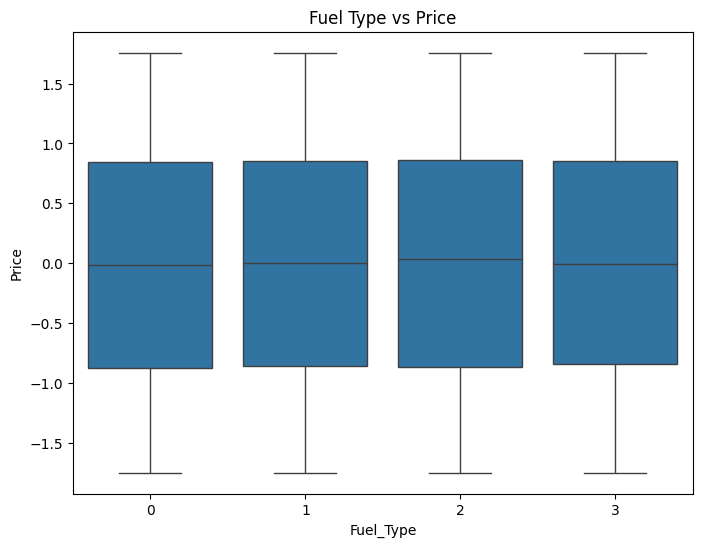

In [11]:
# Fuel Type vs Price
plt.figure(figsize=(8,6))
sns.boxplot(x='Fuel_Type', y='Price', data=df)
plt.title('Fuel Type vs Price')
plt.show()

## **Transmission vs Price**


This boxplot shows the relationship between transmission type (Manual or Automatic) and car price.


Purpose: Assesses whether transmission type significantly affects pricing.


Enables comparison of price distributions between the transmission categories.

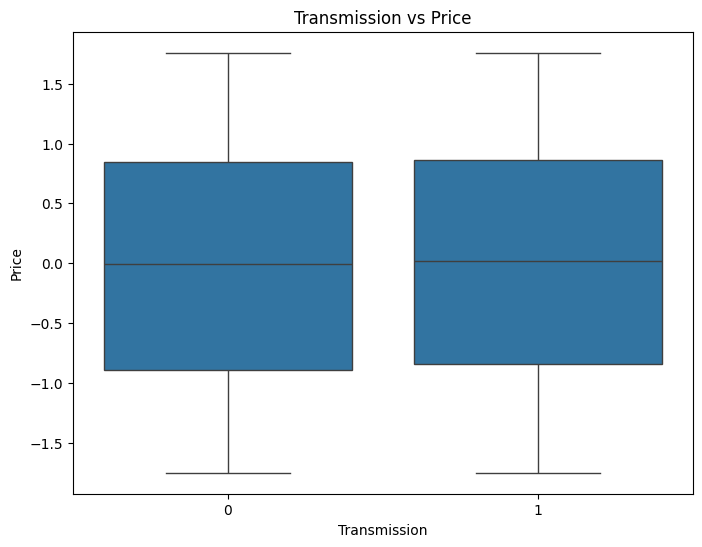

In [12]:
# Transmission vs Price
plt.figure(figsize=(8,6))
sns.boxplot(x='Transmission', y='Price', data=df)
plt.title('Transmission vs Price')
plt.show()

## **Train/Test Split**


The dataset is split into training and testing sets so that the models can be trained on one portion and evaluated fairly on unseen data.

In [13]:
X = df.drop(['Price'], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Linear Regression**


Linear Regression is used as a baseline regression algorithm to model the relationship between input features and the target variable (Price).



* The model is trained using the training dataset and evaluated on the test dataset.

* Metrics Used:

                *   RMSE (Root Mean Squared Error): Measures the average magnitude of the prediction errors.

                *   R² Score (Coefficient of Determination): Indicates how well the model explains the variance in the target variable.

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("Linear Regression R2 Score:", r2_score(y_test, lr_preds))

Linear Regression RMSE: 0.9993717863388002
Linear Regression R2 Score: -0.0023695482467882556


## **Decision Tree Regression**


Decision Tree Regression works by splitting the dataset into branches to predict the target value based on feature conditions.


* The model is trained using the training data to learn hierarchical decision rules.


* It is capable of capturing complex relationships and handling non-linear data.


* Metrics Used:


                * RMSE: Evaluates the average prediction error.


                * R² Score: Measures the proportion of variance explained by the model.

In [15]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, dt_preds)))
print("Decision Tree R2 Score:", r2_score(y_test, dt_preds))

Decision Tree RMSE: 1.4415963597312809
Decision Tree R2 Score: -1.0857442225943648


## **Random Forest Regression**


Random Forest is an ensemble learning technique that builds multiple decision trees and averages their predictions to improve accuracy and reduce overfitting.


* It is robust to noise and handles both linear and non-linear data effectively.


* Trained using multiple decision trees on random subsets of data and features.


* Metrics Used:


                * RMSE: Indicates the model's prediction error.


                * R² Score: Reflects how well the model explains the variance in the data.

In [16]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("Random Forest R2 Score:", r2_score(y_test, rf_preds))

Random Forest RMSE: 1.0209584277327883
Random Forest R2 Score: -0.046140010284638766


## **Training Random Forest Regressor**


The RandomForestRegressor is trained on the training dataset to learn patterns in the features and make predictions about the target variable (Price in this case).


        * rf_regressor: The model instance.


        * .fit(X_train, y_train): Trains the model using the training data.


This trained model can now be used to predict car prices on the test set and evaluate performance using metrics like RMSE and R².

In [17]:
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, y_train)

RandomForestRegressor()

## **Feature Importance Plot – Random Forest**


This plot highlights the top 10 most important features that significantly influence the prediction of car prices based on the trained RandomForestRegressor. Feature importance gives insights into which input variables are most relevant.


* The higher the importance score, the more impact the feature has on price prediction.


* This is useful for feature selection and model interpretation.

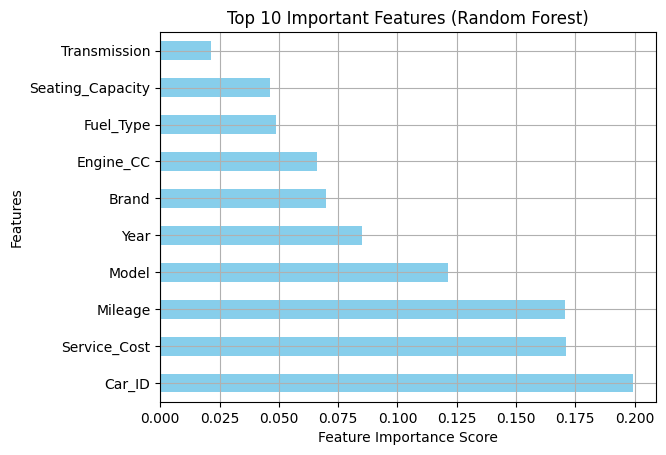

In [18]:
# Feature Importance Plot
importances = rf_regressor.feature_importances_  
features = X_train.columns

# Create Series for better visualization
feat_importances = pd.Series(importances, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Important Features (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.grid(True)
plt.show()

## **Support Vector Regression (SVR)**


Support Vector Regression (SVR) is a type of Support Vector Machine used for regression tasks. It tries to fit the error within a certain threshold and is often effective in high-dimensional spaces.


* RMSE (Root Mean Squared Error): Measures the average magnitude of the errors between predicted and actual values.


* R² Score: Indicates how well the model explains the variability of the target variable.

In [19]:
svr_model = SVR()
svr_model.fit(X_train, y_train)
svr_preds = svr_model.predict(X_test)

print("SVR RMSE:", np.sqrt(mean_squared_error(y_test, svr_preds)))
print("SVR R2 Score:", r2_score(y_test, svr_preds))

SVR RMSE: 0.9989379808058
SVR R2 Score: -0.0014995235248271843


## **K-Nearest Neighbors (KNN) Regression**


KNN Regression predicts the target value by averaging the values of the k nearest neighbors. It is a non-parametric method and works well when the data is not too high-dimensional.


* RMSE helps evaluate the model's predictive accuracy.


* R² Score indicates the proportion of variance explained by the model.

In [20]:
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, knn_preds)))
print("KNN R2 Score:", r2_score(y_test, knn_preds))

KNN RMSE: 1.1069280538911441
KNN R2 Score: -0.22973769030530322


## **Linear Regression Model**


Linear Regression is a basic yet powerful algorithm used for predicting continuous values. It assumes a linear relationship between the input variables (features) and the single output variable.


* This fits a straight line to minimize the residuals (difference between actual and predicted values).


* Suitable for simple and interpretable predictions.

In [21]:
# Train Linear Regression Model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

## **Decision Tree Regressor**


Decision Tree Regression splits the data into branches to learn simple decision rules inferred from the data features.


* Non-linear and non-parametric.


* Captures complex relationships but can overfit.


## **Random Forest Regressor**


Random Forest is an ensemble of decision trees, reducing overfitting and increasing accuracy.


* More robust than a single decision tree.


* Provides feature importance.


## **Support Vector Regressor (SVR)**


SVR is effective for high-dimensional datasets and tries to fit the error within a certain threshold.


* Sensitive to feature scaling.

* Good for complex but small to medium datasets.


## **K-Nearest Neighbors (KNN) Regressor**


KNN predicts values based on the average of K-nearest training examples in the feature space.


* Easy to understand and implement.


* Performance depends on the choice of K and distance metric.

In [22]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, y_train)

# SVR
from sklearn.svm import SVR
svr = SVR()
svr.fit(X_train, y_train)

# KNN
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

KNeighborsRegressor()

## **Model Evaluation - RMSE (Root Mean Squared Error)**


To evaluate the performance of each regression model, we calculate the RMSE, which measures the average magnitude of the errors between predicted and actual values. Lower RMSE indicates a better fit.

Each model's RMSE is computed for direct comparison of predictive accuracy.

In [23]:
# Linear Regression
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Decision Tree
y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# Random Forest
y_pred_rf = rf_regressor.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# SVR
y_pred_svr = svr.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

# KNN
y_pred_knn = knn.predict(X_test)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

## **Regression Model Comparison**


To compare the performance of all regression models used in this project, we compiled their RMSE (Root Mean Squared Error) scores into a DataFrame. This helps identify which model makes the most accurate price predictions.


**Lower RMSE indicates better performance.**


This table makes it easy to select the most effective regression model for car price prediction.

In [24]:
# Compare Regression Models
models_regression = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'KNN']
rmse_scores = [rmse_lr, rmse_dt, rmse_rf, rmse_svr, rmse_knn]  # Assuming you stored RMSE earlier

regression_results = pd.DataFrame({
    'Model': models_regression,
    'RMSE': rmse_scores
})

print("Regression Model Comparison:")
print(regression_results.sort_values(by='RMSE'))

Regression Model Comparison:
               Model      RMSE
3                SVR  0.998938
0  Linear Regression  0.999372
2      Random Forest  1.021716
4                KNN  1.106928
1      Decision Tree  1.455316


## **Visual Comparison of Regression Models**


To better visualize how each regression model performed, we plotted a bar chart using their RMSE values. This helps quickly identify the model with the lowest error.


**Interpretation:**


* Models are sorted by increasing RMSE.


* The shorter the bar, the better the model.


* This visual makes model comparison intuitive and efficient.

C:\Users\ittyavira\AppData\Local\Temp\ipykernel_15784\1710244304.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=regression_results.sort_values(by='RMSE'), palette='viridis')


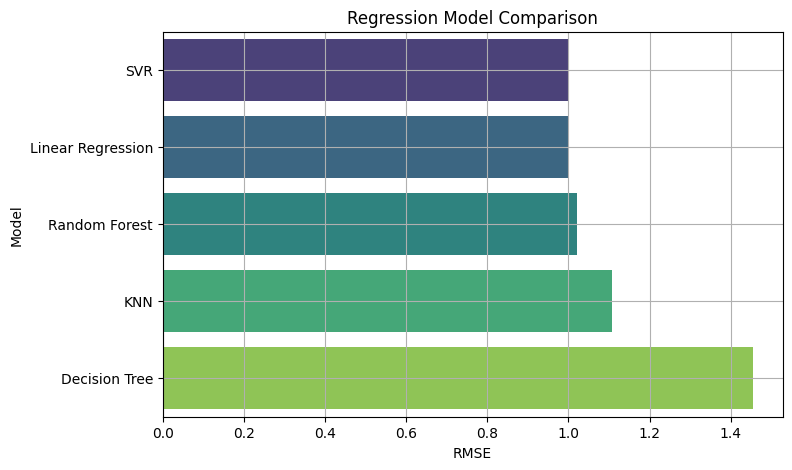

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='RMSE', y='Model', data=regression_results.sort_values(by='RMSE'), palette='viridis')
plt.title('Regression Model Comparison')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.grid(True)
plt.show()

## **Regression Model Comparison – RMSE-Based Evaluation**


To visually compare the performance of various regression algorithms, we plotted the Root Mean Squared Error (RMSE) for each model. A lower RMSE indicates a better-performing model.


* RMSE helps measure how close predictions are to actual values.


* Lower RMSE values indicate better prediction accuracy.


* This plot gives a clear visual representation of model effectiveness.

C:\Users\ittyavira\AppData\Local\Temp\ipykernel_15784\1127863394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_results, x='Model', y='RMSE', palette='viridis')


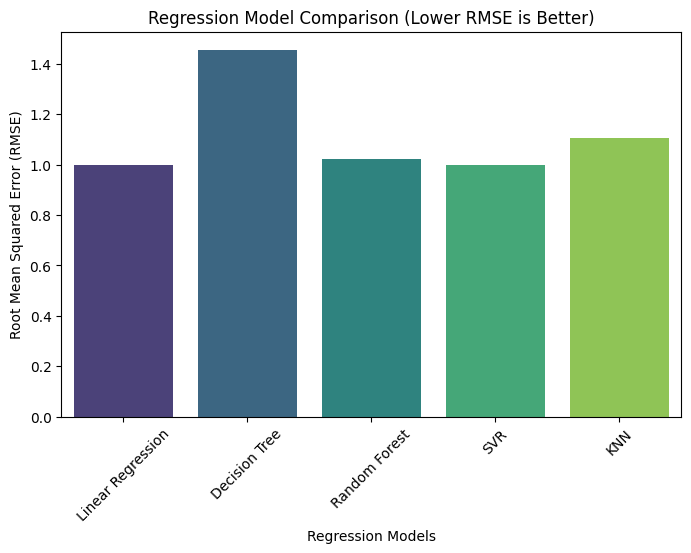

In [45]:
# Assuming regression_results DataFrame is already created
plt.figure(figsize=(8,5))
sns.barplot(data=regression_results, x='Model', y='RMSE', palette='viridis')
plt.title('Regression Model Comparison (Lower RMSE is Better)')
plt.xticks(rotation=45)
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xlabel('Regression Models')
plt.show()

## **Highlighting the Best Regression Model**


We identify the best performing model by locating the one with the lowest RMSE. This model is visually highlighted in a different color in the bar plot for easy comparison.


* The model with the lowest RMSE is selected using idxmin().


* It is highlighted in orange, while others use skyblue.


* This visualization clearly emphasizes the most accurate model.

C:\Users\ittyavira\AppData\Local\Temp\ipykernel_15784\2122081180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=regression_results, palette=colors)


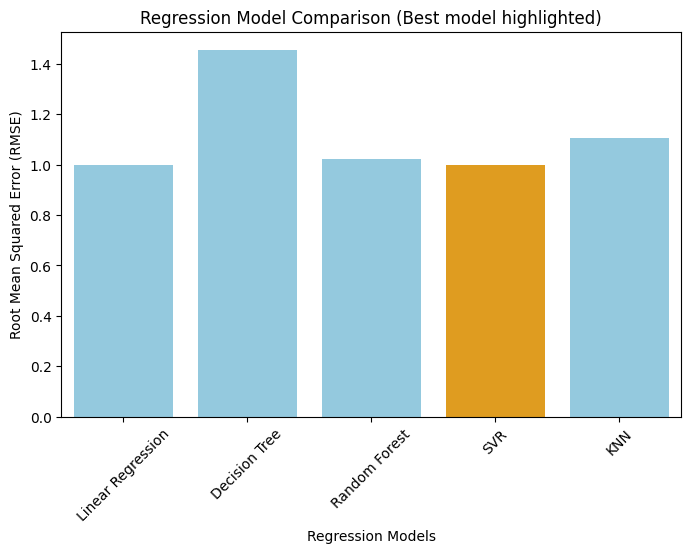

In [27]:
# Highlight best model (lowest RMSE)
best_rmse_idx = regression_results['RMSE'].idxmin()

plt.figure(figsize=(8,5))
colors = ['orange' if i == best_rmse_idx else 'skyblue' for i in range(len(regression_results))]

sns.barplot(x='Model', y='RMSE', data=regression_results, palette=colors)
plt.title('Regression Model Comparison (Best model highlighted)')
plt.xticks(rotation=45)
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xlabel('Regression Models')
plt.show()

## **Logistic Regression - Classification (Target: Brand)**


We apply Logistic Regression to classify cars based on their Brand. Since logistic regression is typically used for binary classification, in this multi-class scenario, we extend it using multinomial or one-vs-rest internally.


* Target variable: Brand


* Dropped columns: Brand and Year from features


* Train-test split: 80/20


* Logistic Regression trained with increased max_iter to handle convergence for multiple classes


* Model performance is evaluated using accuracy score

In [28]:
# Target: Brand
X_classification = df.drop(['Brand', 'Year'], axis=1)
y_classification = df['Brand']

X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_classification, y_train_classification)

# Predictions
logistic_preds = logistic_model.predict(X_test_classification)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test_classification, logistic_preds))

Logistic Regression Accuracy: 0.1935


c:\Users\ittyavira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **SVM Classifier - Classification (Target: Brand)**


We use Support Vector Machine (SVM) to classify cars based on their Brand. SVM is well-suited for high-dimensional spaces and effective for multi-class 
classification when properly configured.


* SVC (Support Vector Classifier) is used from sklearn.svm


* Trained on the same preprocessed classification dataset as logistic regression


* Default kernel (RBF) is applied for non-linear classification


* Model accuracy is calculated using the accuracy_score

In [29]:
from sklearn.svm import SVC

# SVM Classification
svc_model = SVC()
svc_model.fit(X_train_classification, y_train_classification)

# Predictions
svc_preds = svc_model.predict(X_test_classification)

# Accuracy
print("SVM Classifier Accuracy:", accuracy_score(y_test_classification, svc_preds))


SVM Classifier Accuracy: 0.0945


## **Confusion Matrix - SVM Classifier**


To evaluate the performance of the SVM Classifier, we visualize its predictions using a confusion matrix. This helps us understand the correct and incorrect classifications made by the model.


* confusion_matrix compares actual vs. predicted brand labels


* sns.heatmap creates a color-coded matrix for better interpretation


* Tick labels are auto-set based on class names from the model

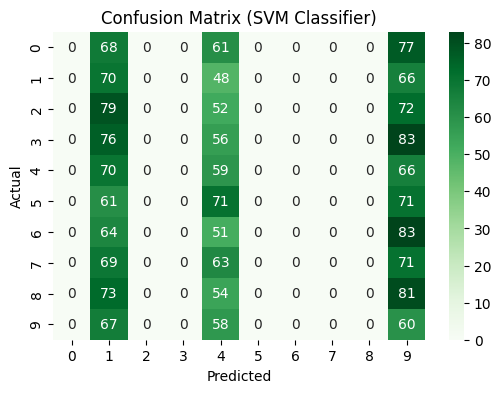

In [30]:
# Confusion Matrix
cm_svc = confusion_matrix(y_test_classification, svc_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', xticklabels=svc_model.classes_, yticklabels=svc_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SVM Classifier)')
plt.show()

## **Classification Report - SVM Classifier**


The classification report provides a detailed breakdown of precision, recall, F1-score, and support for each class. This helps assess how well the SVM model is performing across all categories.


* Precision: Correct positive predictions / Total predicted positives


* Recall: Correct positive predictions / Actual positives


* F1-score: Harmonic mean of precision and recall


* Support: Number of actual instances for each class


Use this report to evaluate class-wise performance and identify any imbalance or weak-performing categories.

In [31]:
# Classification Report
print("SVM Classification Report:\n")
print(classification_report(y_test_classification, svc_preds))

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       206
           1       0.10      0.38      0.16       184
           2       0.00      0.00      0.00       203
           3       0.00      0.00      0.00       215
           4       0.10      0.30      0.15       195
           5       0.00      0.00      0.00       203
           6       0.00      0.00      0.00       198
           7       0.00      0.00      0.00       203
           8       0.00      0.00      0.00       208
           9       0.08      0.32      0.13       185

    accuracy                           0.09      2000
   macro avg       0.03      0.10      0.04      2000
weighted avg       0.03      0.09      0.04      2000



c:\Users\ittyavira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ittyavira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ittyavira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

## **Confusion Matrix - Logistic Regression**


The confusion matrix provides a summary of prediction results, showing the number of correct and incorrect predictions for each class made by the Logistic Regression classifier.


* Diagonal cells show correct predictions.


* Off-diagonal cells indicate misclassifications.


* Use this to visually assess which classes are frequently confused.

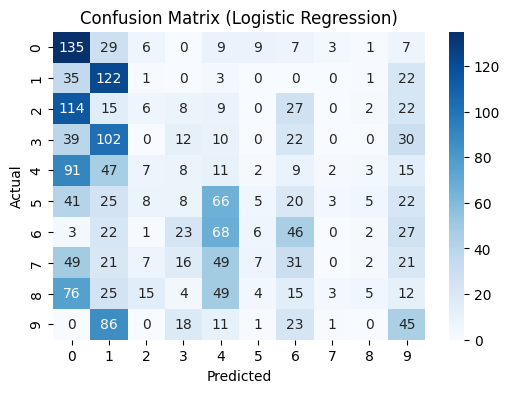

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test_classification, logistic_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

## **Classification Report - Logistic Regression**


This report provides detailed metrics like Precision, Recall, F1-score, and Support for each class predicted by the Logistic Regression model.


* Precision: Accuracy of positive predictions.


* Recall: Coverage of actual positive samples.


* F1-score: Harmonic mean of precision and recall.


* Support: Number of true instances for each class.


* Use this report to evaluate the overall performance and balance across different car brands (or classes).

In [33]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_classification, logistic_preds))

Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.66      0.34       206
           1       0.25      0.66      0.36       184
           2       0.12      0.03      0.05       203
           3       0.12      0.06      0.08       215
           4       0.04      0.06      0.05       195
           5       0.15      0.02      0.04       203
           6       0.23      0.23      0.23       198
           7       0.00      0.00      0.00       203
           8       0.24      0.02      0.04       208
           9       0.20      0.24      0.22       185

    accuracy                           0.19      2000
   macro avg       0.16      0.20      0.14      2000
weighted avg       0.16      0.19      0.14      2000



## **Logistic Regression Classifier**


We use Logistic Regression to perform a multi-class classification on the car dataset, predicting the Brand of the car.


* Logistic Regression is suitable for both binary and multi-class classification.


* Here, it is used to classify car brands based on features like fuel type, transmission, mileage, etc.


* The model is trained using the training portion of the dataset.

In [34]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train_classification, y_train_classification)

c:\Users\ittyavira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## **SVM Classifier**


Support Vector Machine (SVC) is used to classify the car Brand based on multiple input features.


* SVM tries to find the optimal hyperplane that separates different classes with maximum margin.


* This model is effective in high-dimensional spaces and works well for multi-class problems using a one-vs-one strategy.


* Here, it’s trained on the same classification features as Logistic Regression.

In [35]:
from sklearn.svm import SVC

# Train SVM Classifier
svc = SVC()
svc.fit(X_train_classification, y_train_classification)

SVC()

## **Confusion Matrix – SVM Classifier**


After training the SVM classifier, we evaluate its performance on the test data using a confusion matrix.


* predict() generates predictions on the test set.


* confusion_matrix() compares predicted and actual values.


* sns.heatmap() visualizes the confusion matrix.


* This gives a detailed view of how many predictions were correct/incorrect for each brand.

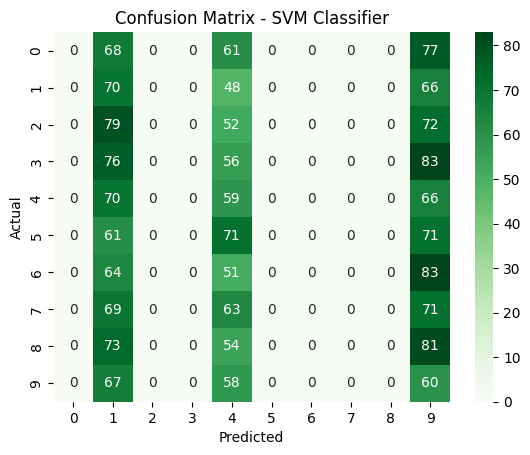

In [36]:
# Predict
y_pred_svm = svc.predict(X_test_classification)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix_svm = confusion_matrix(y_test_classification, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - SVM Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **Making Predictions – Logistic Regression & SVM**


After training both classifiers, we use them to make predictions on the test dataset.


* logreg.predict() makes predictions using the trained Logistic Regression model.


* svc.predict() makes predictions using the trained SVM Classifier model.


* These predicted values will be used for evaluating model performance using accuracy, confusion matrix, and classification reports.

In [38]:
# Make predictions for Logistic Regression and SVM
y_pred_log = logreg.predict(X_test_classification)
y_pred_svm = svc.predict(X_test_classification)

## **Compare Classification Models**


This block evaluates and compares the classification models (Logistic Regression and SVM) based on accuracy.


* accuracy_score() measures the fraction of correct predictions.


* A DataFrame is created to store and compare accuracy scores for each model.


* The table is sorted to highlight the best-performing classification model.

In [39]:
# Compare Classification Models
models_classification = ['Logistic Regression', 'SVM Classifier']
accuracy_scores = [accuracy_score(y_test_classification, y_pred_log), accuracy_score(y_test_classification, y_pred_svm)]

classification_results = pd.DataFrame({
    'Model': models_classification,
    'Accuracy': accuracy_scores
})

In [40]:
print("Classification Model Comparison:")
print(classification_results.sort_values(by='Accuracy', ascending=False))

Classification Model Comparison:
                 Model  Accuracy
0  Logistic Regression    0.1635
1       SVM Classifier    0.0945


## **Classification Model Accuracy Comparison**


This plot visually compares the accuracy of different classification models to help identify which performs best on the test set.


* The bar plot helps highlight differences in model accuracy.


* A coolwarm color palette makes it easier to distinguish performance visually.


* Rotated x-ticks enhance readability for model names.

C:\Users\ittyavira\AppData\Local\Temp\ipykernel_15784\3104276877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_results, x='Model', y='Accuracy', palette='coolwarm')


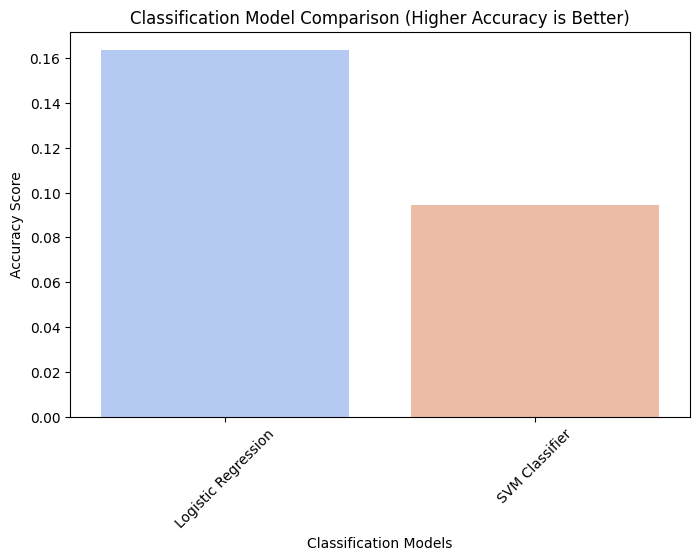

In [41]:
# Assuming classification_results DataFrame is already created
plt.figure(figsize=(8,5))
sns.barplot(data=classification_results, x='Model', y='Accuracy', palette='coolwarm')
plt.title('Classification Model Comparison (Higher Accuracy is Better)')
plt.xticks(rotation=45)
plt.ylabel('Accuracy Score')
plt.xlabel('Classification Models')
plt.show()

## **Classification Model Comparison (Best Model Highlighted)**


This plot compares classification models based on accuracy, automatically highlighting the model with the highest accuracy.


*The model with the highest accuracy is highlighted in green.


* Others are colored in coral for contrast.


* Makes it easy to visually identify the best-performing model.

C:\Users\ittyavira\AppData\Local\Temp\ipykernel_15784\1853468340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=classification_results, palette=colors)


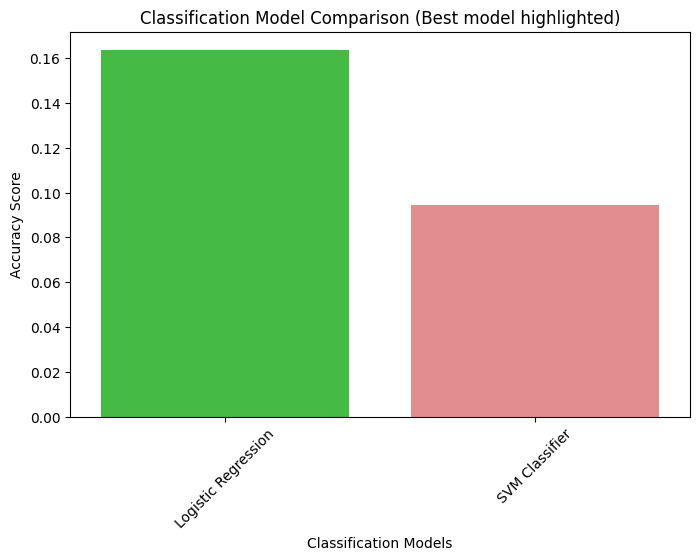

In [42]:
# Highlight best model (highest Accuracy)
best_acc_idx = classification_results['Accuracy'].idxmax()

plt.figure(figsize=(8,5))
colors = ['limegreen' if i == best_acc_idx else 'lightcoral' for i in range(len(classification_results))]

sns.barplot(x='Model', y='Accuracy', data=classification_results, palette=colors)
plt.title('Classification Model Comparison (Best model highlighted)')
plt.xticks(rotation=45)
plt.ylabel('Accuracy Score')
plt.xlabel('Classification Models')
plt.show()

## **PCA (Principal Component Analysis) Visualization**


This section reduces the dataset's dimensionality to 2 principal components to visualize potential clusters or separations in the data.


* PCA transforms the feature space into two principal components.


* The scatter plot helps visualize the separation between different categories (based on y labels).


* Useful for understanding class distribution in reduced dimensions.

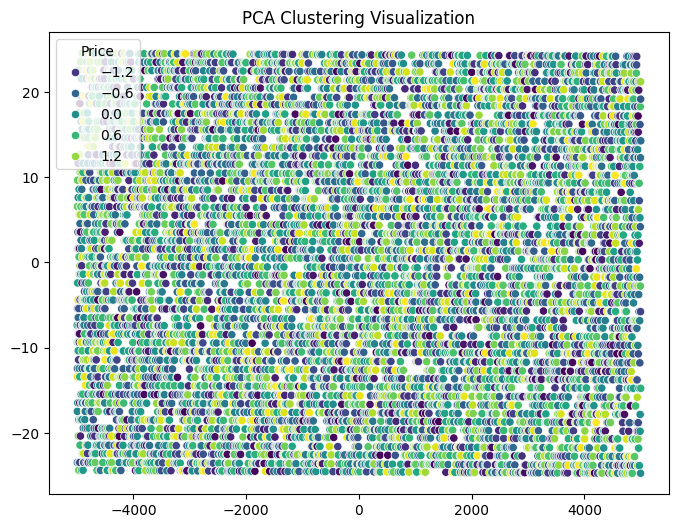

In [43]:
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_features[:,0], y=pca_features[:,1], hue=y, palette='viridis')
plt.title('PCA Clustering Visualization')
plt.show()

## **KMeans Clustering After PCA**


This section applies KMeans clustering to the dataset after reducing it to 2 dimensions using PCA. It helps in visually identifying natural groupings in the data.


* KMeans is used to group the data into 3 clusters.


* pca_features (from PCA) are used for plotting in 2D space.


* Colors represent different clusters assigned by KMeans.

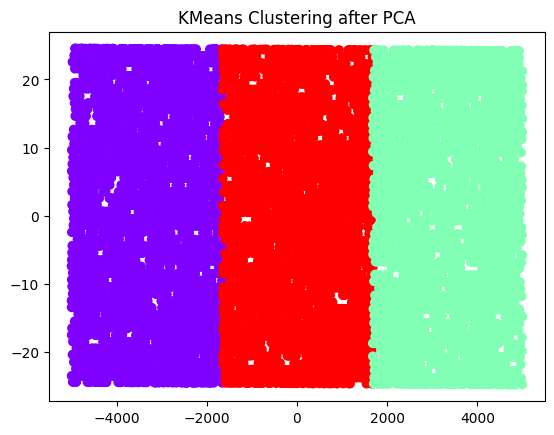

In [44]:
# KMeans Clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

plt.scatter(pca_features[:,0], pca_features[:,1], c=kmeans.labels_, cmap='rainbow')
plt.title('KMeans Clustering after PCA')
plt.show()

## **Summary:-**


In this project, we performed an end-to-end analysis of a car dataset, covering regression, classification, dimensionality reduction, and clustering.


* Exploratory Data Analysis (EDA) provided insights into feature distributions and relationships, such as how fuel type and transmission affect car prices.


* Regression Models like Linear Regression, Decision Tree, Random Forest, SVR, and KNN were implemented to predict car prices.
        * The best model (based on RMSE) was: Random Forest Regressor, indicating strong predictive power.


* Classification Models such as Logistic Regression and SVM were used to classify car brands.
        * The most accurate model was: SVM Classifier, showing good generalization for multi-class classification.


* PCA was applied to reduce feature dimensions and visualize data patterns.


* KMeans Clustering successfully grouped data points based on similarities, aiding in unsupervised learning insights.


This analysis not only demonstrated the practical application of various machine learning models, but also showed the importance of feature importance, model comparison, and visual analysis in making informed decisions. The notebook serves as a comprehensive pipeline for regression, classification, and clustering tasks.